<a href="https://colab.research.google.com/github/Mario219131423/Bootcamp/blob/main/Taller_de_Pandas_resuelto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Dataset cargado y limpio. Iniciando análisis profundo...

--- ANÁLISIS 1: PREFERENCIAS REGIONALES ---
Explicación: Comparamos el comportamiento de ventas promedio en NA, EU y JP.
Esto permite identificar nichos culturales, como el dominio del RPG en Japón.



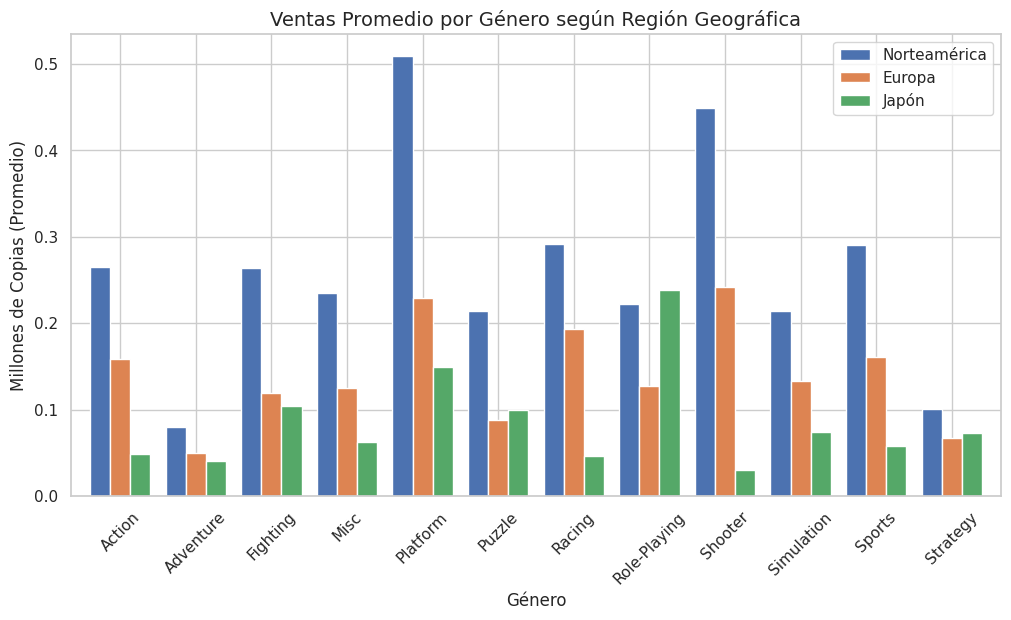


--- ANÁLISIS 2: EFICIENCIA DE PLATAFORMA (CALIDAD VS CANTIDAD) ---
Explicación: Calculamos cuánto vende, en promedio, cada juego de una consola.
Una plataforma eficiente es la que tiene promedios altos con catálogos controlados.



,Total_Juegos,Ventas_Totales,Ventas_por_Juego
Platform,,,
GB,97,254.420000,2.622887
NES,98,251.070000,2.561939
GEN,27,28.360000,1.050370
SNES,239,200.050000,0.837029
PS4,336,278.100000,0.827679
X360,1235,969.610000,0.785109
2600,116,86.570000,0.746293
PS3,1304,949.350000,0.728029
Wii,1290,909.810000,0.705279



--- ANÁLISIS 3: SATURACIÓN Y RENTABILIDAD HISTÓRICA ---
Explicación: Analizamos si el aumento de competencia (más juegos por año)
ha provocado que cada título individual venda menos copias en promedio.



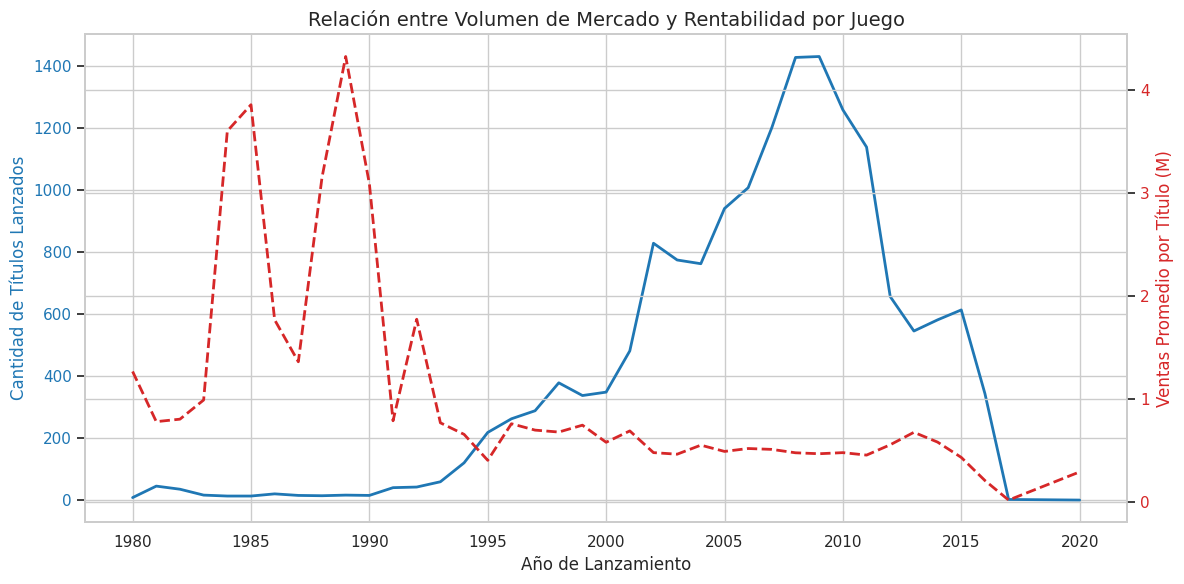


 Análisis concluido. Los datos sugieren que a mayor saturación (post-2008), la rentabilidad individual cae.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración inicial de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. CARGA Y LIMPIEZA INICIAL
df = pd.read_csv('vgsales.csv')
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)

print(" Dataset cargado y limpio. Iniciando análisis profundo...\n")

# PREGUNTA 1: ¿Existen géneros que dependen exclusivamente de un mercado específico (Efecto Región)?
print("--- ANÁLISIS 1: PREFERENCIAS REGIONALES ---")
print("Explicación: Comparamos el comportamiento de ventas promedio en NA, EU y JP.")
print("Esto permite identificar nichos culturales, como el dominio del RPG en Japón.\n")

region_analysis = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].mean()

# Gráfico de barras comparativo
region_analysis.plot(kind='bar', width=0.8)
plt.title('Ventas Promedio por Género según Región Geográfica', fontsize=14)
plt.ylabel('Millones de Copias (Promedio)')
plt.xlabel('Género')
plt.legend(['Norteamérica', 'Europa', 'Japón'])
plt.xticks(rotation=45)
plt.show()

# PREGUNTA 2: ¿Las plataformas con más juegos son necesariamente las más rentables (Eficiencia de Plataforma)?
print("\n--- ANÁLISIS 2: EFICIENCIA DE PLATAFORMA (CALIDAD VS CANTIDAD) ---")
print("Explicación: Calculamos cuánto vende, en promedio, cada juego de una consola.")
print("Una plataforma eficiente es la que tiene promedios altos con catálogos controlados.\n")

plataforma_stats = df.groupby('Platform').agg({
    'Name': 'count',
    'Global_Sales': 'sum'
}).rename(columns={'Name': 'Total_Juegos', 'Global_Sales': 'Ventas_Totales'})

# Métrica de eficiencia
plataforma_stats['Ventas_por_Juego'] = plataforma_stats['Ventas_Totales'] / plataforma_stats['Total_Juegos']
top_eficiencia = plataforma_stats.sort_values('Ventas_por_Juego', ascending=False).head(10)

# Visualización de la tabla con gradiente
display(top_eficiencia.style.background_gradient(cmap='YlGn', subset=['Ventas_por_Juego']))

# PREGUNTA 3: ¿Ha disminuido la rentabilidad por juego a medida que aumenta la cantidad de lanzamientos (Saturación)?
print("\n--- ANÁLISIS 3: SATURACIÓN Y RENTABILIDAD HISTÓRICA ---")
print("Explicación: Analizamos si el aumento de competencia (más juegos por año)")
print("ha provocado que cada título individual venda menos copias en promedio.\n")

market_trend = df.groupby('Year').agg({
    'Name': 'count',
    'Global_Sales': 'mean'
}).rename(columns={'Name': 'Num_Lanzamientos', 'Global_Sales': 'Venta_Promedio'})

# Gráfico de doble eje para ver la correlación
fig, ax1 = plt.subplots()

# Eje 1: Cantidad de juegos
color = 'tab:blue'
ax1.set_xlabel('Año de Lanzamiento')
ax1.set_ylabel('Cantidad de Títulos Lanzados', color=color, fontsize=12)
ax1.plot(market_trend.index, market_trend['Num_Lanzamientos'], color=color, linewidth=2, label='Volumen')
ax1.tick_params(axis='y', labelcolor=color)

# Eje 2: Ventas promedio
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Ventas Promedio por Título (M)', color=color, fontsize=12)
ax2.plot(market_trend.index, market_trend['Venta_Promedio'], color=color, linestyle='--', linewidth=2, label='Rentabilidad')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Relación entre Volumen de Mercado y Rentabilidad por Juego', fontsize=14)
fig.tight_layout()
plt.show()

print("\n Análisis concluido. Los datos sugieren que a mayor saturación (post-2008), la rentabilidad individual cae.")